# RNA Modification Detection Tool Comparison
## Coverage Benchmark — Publication Figures

This notebook generates publication-quality plots comparing 9 RNA modification detection tools across 25 coverage levels (5x–1000x) on two rRNA references (16S rrsE and 23S rrlB).

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# --- Publication style ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.linewidth': 0.8,
    'lines.linewidth': 1.5,
    'lines.markersize': 4,
})

# --- Tool color palette (colorblind-friendly) ---
TOOL_ORDER = ['drummer', 'jacusa2', 'eligos', 'tombo', 'yanocomp',
              'nanocompore', 'xpore', 'epinano', 'differr']

TOOL_COLORS = {
    'drummer':     '#1f77b4',
    'jacusa2':     '#ff7f0e',
    'eligos':      '#2ca02c',
    'tombo':       '#d62728',
    'yanocomp':    '#9467bd',
    'nanocompore': '#8c564b',
    'xpore':       '#e377c2',
    'epinano':     '#7f7f7f',
    'differr':     '#bcbd22',
}

TOOL_MARKERS = {
    'drummer':     'o',
    'jacusa2':     's',
    'eligos':      '^',
    'tombo':       'D',
    'yanocomp':    'v',
    'nanocompore': 'P',
    'xpore':       'X',
    'epinano':     'p',
    'differr':     '*',
}

REF_LABELS = {
    '16s_88_rrsE': '16S rRNA',
    '23s_78_rrlB': '23S rRNA',
}

# --- Output directory ---
FIG_DIR = Path('/absolute/path/to/user/tool_figures/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('Setup complete.')

Setup complete.


In [33]:
# --- Load data ---
df = pd.read_csv('covbench_results/collated_multi_cov/metrics_summary_long.csv')

# Parse coverage_label to numeric for sorting/plotting
df['coverage_num'] = df['coverage_label'].str.replace('x', '').astype(int)
df = df.sort_values(['coverage_num', 'reference', 'tool']).reset_index(drop=True)

# Quick summary
print(f"Shape: {df.shape}")
print(f"Coverage levels: {sorted(df['coverage_num'].unique())}")
print(f"Tools: {sorted(df['tool'].unique())}")
print(f"References: {sorted(df['reference'].unique())}")
print()

# Check differr — all NaN metrics?
differr_check = df[df['tool'] == 'differr'][['auroc_mean', 'auprc_mean', 'f1_optimal_mean']].isna().all()
print(f"differr all NaN for auroc/auprc/f1: {differr_check.to_dict()}")

# Create a filtered df excluding differr for metric plots
df_metrics = df[df['tool'] != 'differr'].copy()
tools_with_metrics = [t for t in TOOL_ORDER if t != 'differr']

df.head()

Shape: (433, 29)
Coverage levels: [np.int64(5), np.int64(10), np.int64(15), np.int64(20), np.int64(25), np.int64(30), np.int64(35), np.int64(40), np.int64(45), np.int64(50), np.int64(55), np.int64(60), np.int64(65), np.int64(70), np.int64(75), np.int64(80), np.int64(85), np.int64(90), np.int64(95), np.int64(100), np.int64(150), np.int64(200), np.int64(500), np.int64(750), np.int64(1000)]
Tools: ['differr', 'drummer', 'eligos', 'epinano', 'jacusa2', 'nanocompore', 'tombo', 'xpore', 'yanocomp']
References: ['16s_88_rrsE', '23s_78_rrlB']

differr all NaN for auroc/auprc/f1: {'auroc_mean': True, 'auprc_mean': True, 'f1_optimal_mean': True}


,run_id,coverage_label,quality_label,reference,tool,auprc_mean,auprc_std,auprc_median,auroc_mean,auroc_std,...,f1_optimal_median,f1_reported_mean,f1_reported_std,f1_reported_median,precision_optimal_mean,recall_optimal_mean,metrics_valid_fraction,no_call_rate_mean,gt_recall_raw_mean,coverage_num
0,run_5x,5x,base,16s_88_rrsE,differr,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.757467,0.878788,5
1,run_5x,5x,base,16s_88_rrsE,eligos,0.035587,0.026493,0.045038,0.652535,0.197054,...,0.140000,0.155156,0.105898,0.142857,0.102179,0.606061,1.0,0.878991,0.696970,5
2,run_5x,5x,base,16s_88_rrsE,epinano,0.009788,0.002283,0.009490,0.669099,0.066927,...,0.022346,0.028730,0.012390,0.022346,0.015607,0.454545,1.0,0.338654,1.000000,5
3,run_5x,5x,base,16s_88_rrsE,jacusa2,0.063143,0.022407,0.075643,0.834840,0.047526,...,0.187500,0.177806,0.054036,0.193548,0.157738,0.212121,1.0,0.498798,0.939394,5
4,run_5x,5x,base,16s_88_rrsE,nanocompore,0.007764,0.002362,0.006932,0.610659,0.099053,...,0.014665,0.017466,0.003951,0.017182,0.008272,0.818182,1.0,0.351184,0.969697,5


## Reusable Line Plot Function

In [34]:
PREVALENCE = {
    '16s_88_rrsE': 11 / 1942,   # ~0.00566
    '23s_78_rrlB': 25 / 3304,   # ~0.00757
}

def plot_metric_vs_coverage(df, metric_mean, metric_std, ylabel, title, filename,
                            tools=None, ylim=None, baseline_hlines=None,
                            baseline_label=None):
    """
    Line plot: metric vs coverage for each tool, with 16S on top and 23S on bottom.
    Shaded error bands from std.

    baseline_hlines: dict {reference: y_value} to draw a dashed horizontal baseline per panel.
    baseline_label: text label for the baseline line.
    """
    if tools is None:
        tools = tools_with_metrics

    refs = ['16s_88_rrsE', '23s_78_rrlB']
    fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

    for ax, ref in zip(axes, refs):
        sub = df[df['reference'] == ref]
        for tool in tools:
            t = sub[sub['tool'] == tool].sort_values('coverage_num')
            if t.empty or t[metric_mean].isna().all():
                continue
            x = t['coverage_num'].values
            y = t[metric_mean].values
            ax.plot(x, y, color=TOOL_COLORS[tool], marker=TOOL_MARKERS[tool],
                    label=tool, markeredgecolor='white', markeredgewidth=0.3)
            if metric_std and metric_std in t.columns:
                yerr = t[metric_std].values
                ax.fill_between(x, y - yerr, y + yerr,
                                color=TOOL_COLORS[tool], alpha=0.12)

        # Draw baseline if provided
        if baseline_hlines and ref in baseline_hlines:
            bval = baseline_hlines[ref]
            ax.axhline(y=bval, color='black', linestyle='--', linewidth=0.8, alpha=0.6)
            blabel = baseline_label or f'{bval:.4f}'
            ax.text(0.98, bval, f' {blabel}', transform=ax.get_yaxis_transform(),
                    va='bottom', ha='right', fontsize=7, color='black', alpha=0.7)

        ax.set_xscale('log')
        ax.set_ylabel(ylabel)
        ax.set_title(REF_LABELS[ref], fontweight='bold')
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{int(v)}x'))
        ax.set_xticks([5, 10, 25, 50, 100, 200, 500, 1000])
        if ylim:
            ax.set_ylim(ylim)

    axes[1].set_xlabel('Coverage')

    # Panel labels
    for i, label in enumerate(['A', 'B']):
        axes[i].text(-0.05, 1.05, label, transform=axes[i].transAxes,
                     fontsize=13, fontweight='bold', va='top')

    # Shared legend below
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=min(len(tools), 8),
               bbox_to_anchor=(0.5, -0.02), frameon=True)

    fig.suptitle(title, fontsize=12, fontweight='bold', y=1.02)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f'{filename}.pdf', bbox_inches='tight')
    fig.savefig(FIG_DIR / f'{filename}.png', bbox_inches='tight')
    plt.show()
    return fig

## Figure 1: AUROC vs Coverage

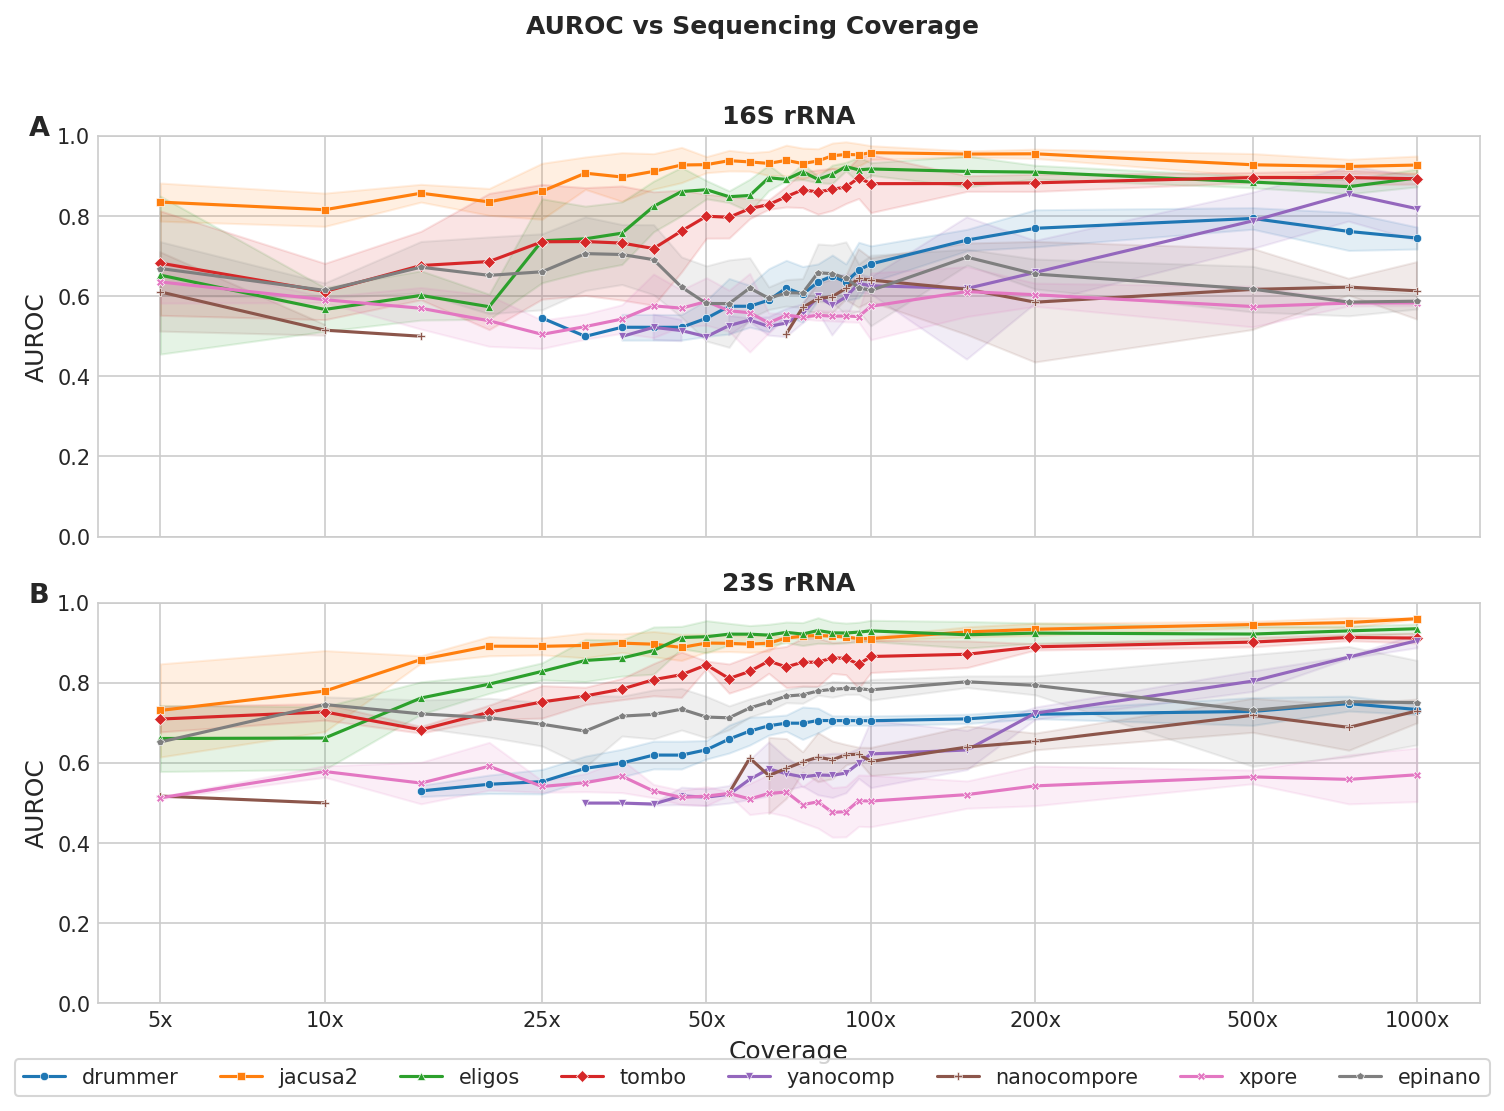

In [35]:
fig_auroc = plot_metric_vs_coverage(
    df_metrics,
    metric_mean='auroc_mean', metric_std='auroc_std',
    ylabel='AUROC',
    title='AUROC vs Sequencing Coverage',
    filename='auroc_vs_coverage',
    ylim=(0, 1.0),
)

## Figure 2: AUPRC vs Coverage

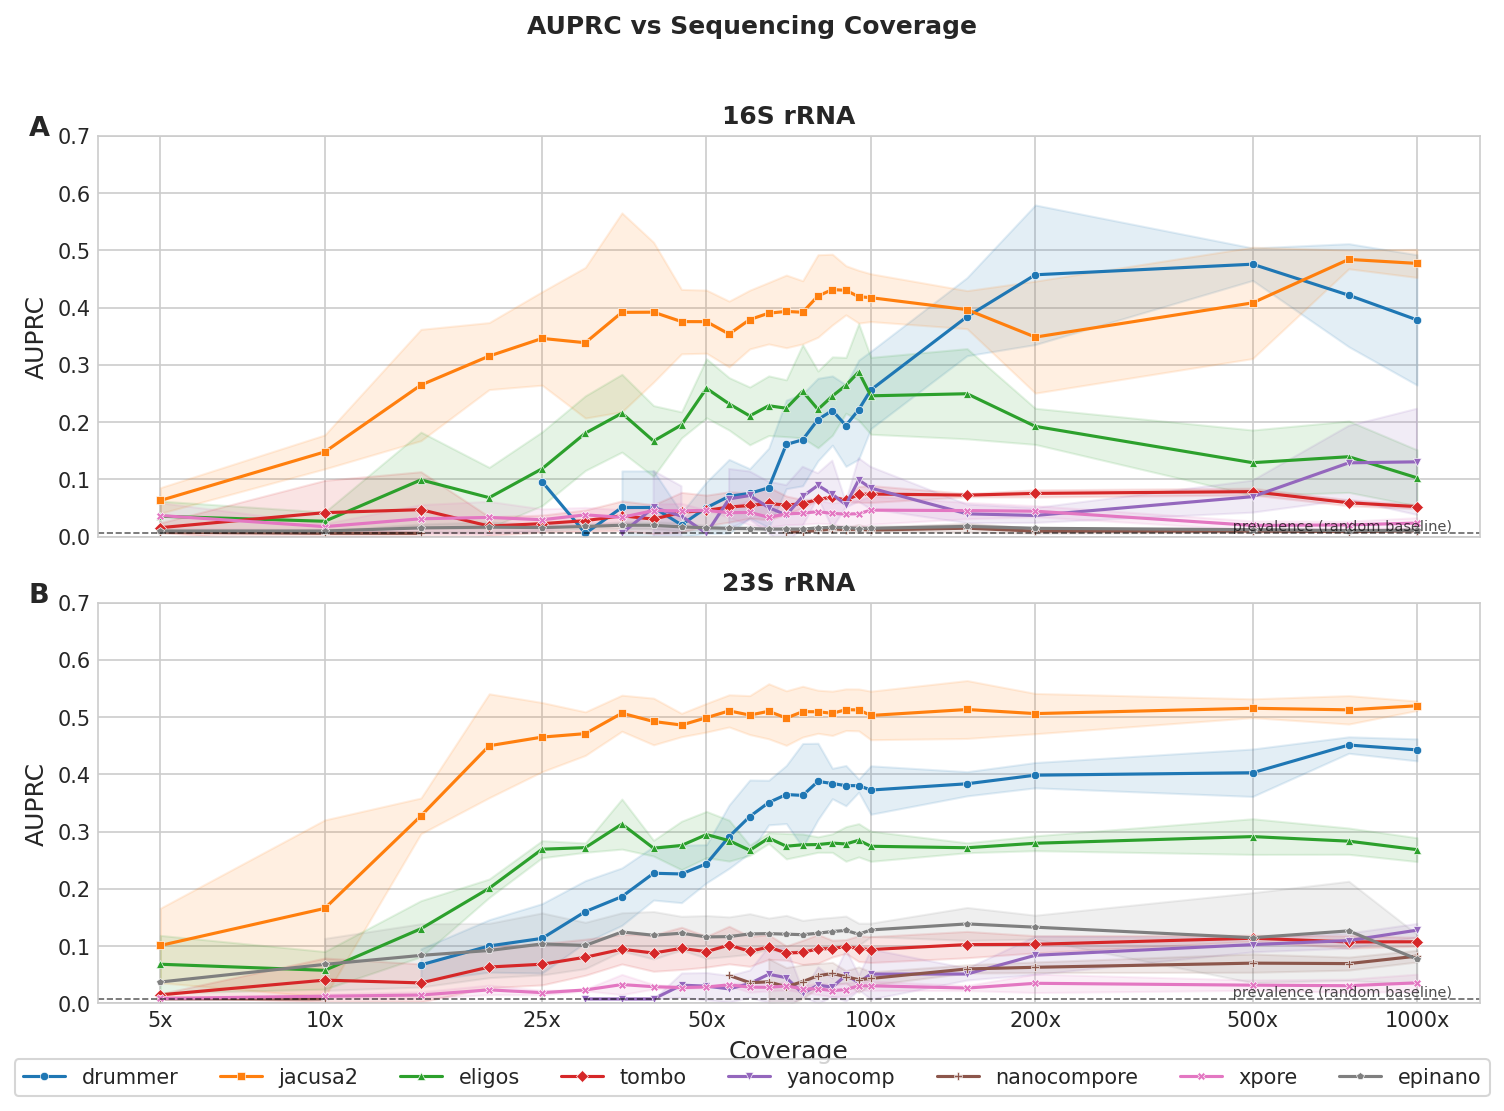

In [36]:
fig_auprc = plot_metric_vs_coverage(
    df_metrics,
    metric_mean='auprc_mean', metric_std='auprc_std',
    ylabel='AUPRC',
    title='AUPRC vs Sequencing Coverage',
    filename='auprc_vs_coverage',
    ylim=(0.0, 0.7),
    baseline_hlines=PREVALENCE,
    baseline_label='prevalence (random baseline)',
)

## Figure 2b: AUPRC Ratio (fold improvement over random)

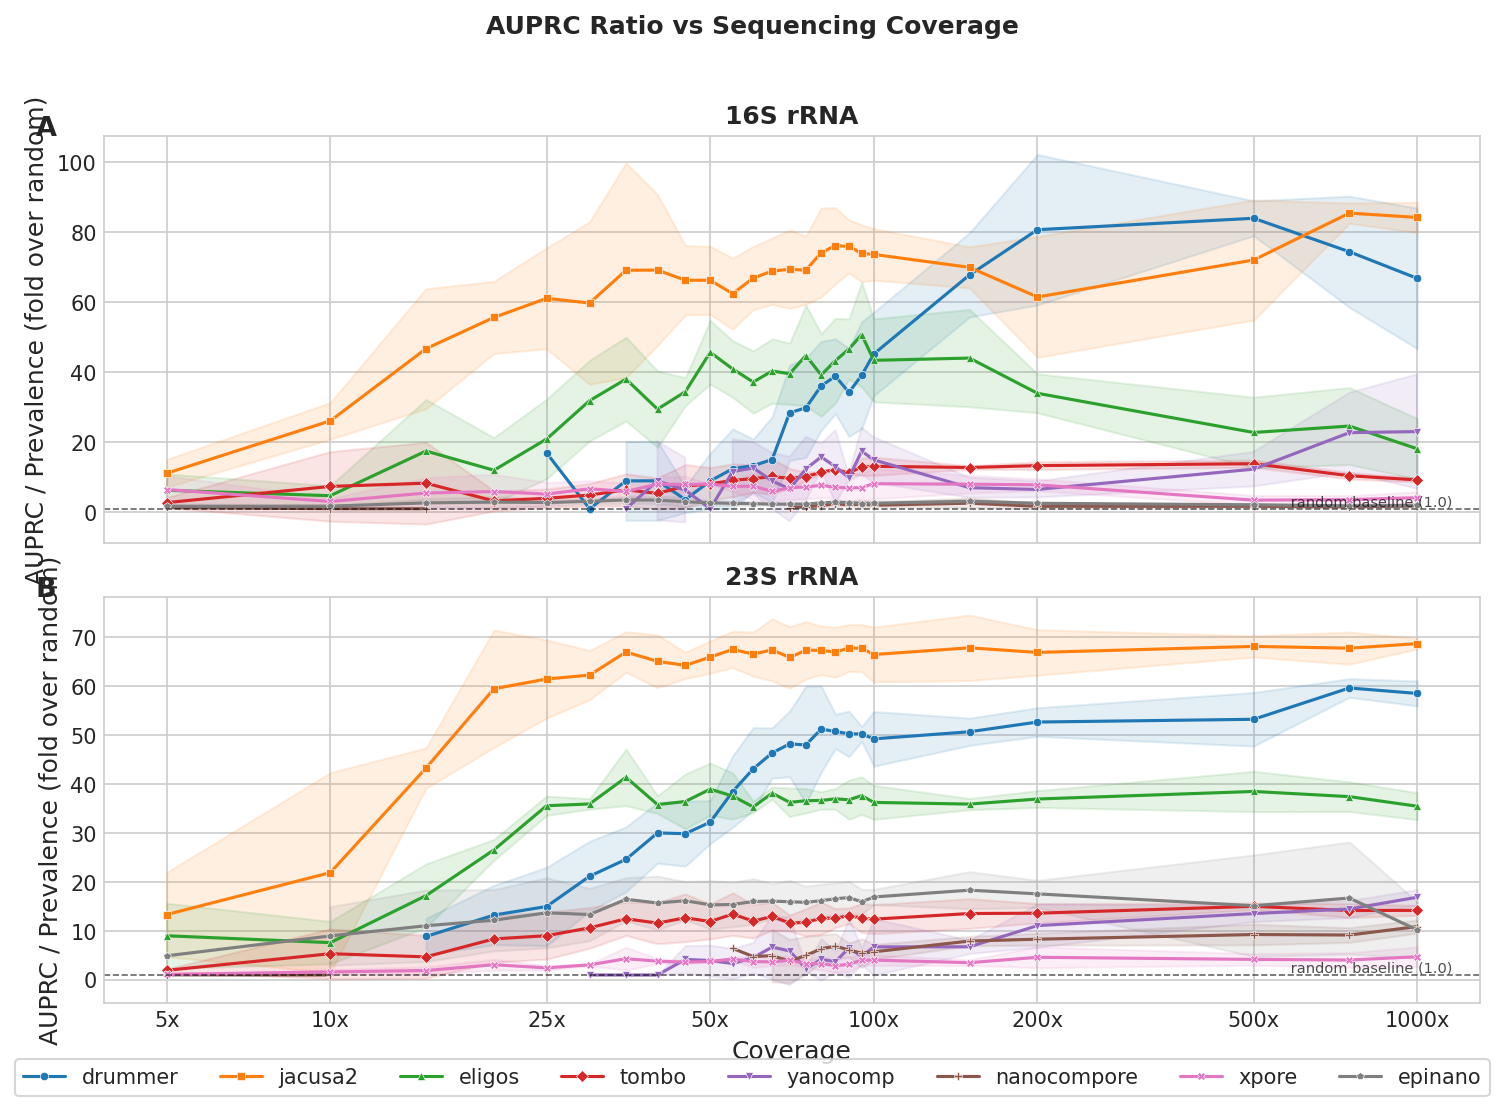

In [37]:
# Compute AUPRC ratio (fold improvement over random) per reference
df_ratio = df_metrics.copy()
df_ratio['auprc_ratio'] = df_ratio.apply(
    lambda r: r['auprc_mean'] / PREVALENCE[r['reference']]
    if pd.notna(r['auprc_mean']) else np.nan, axis=1)
df_ratio['auprc_ratio_std'] = df_ratio.apply(
    lambda r: r['auprc_std'] / PREVALENCE[r['reference']]
    if pd.notna(r['auprc_std']) else np.nan, axis=1)

fig_auprc_ratio = plot_metric_vs_coverage(
    df_ratio,
    metric_mean='auprc_ratio', metric_std='auprc_ratio_std',
    ylabel='AUPRC / Prevalence (fold over random)',
    title='AUPRC Ratio vs Sequencing Coverage',
    filename='auprc_ratio_vs_coverage',
    baseline_hlines={'16s_88_rrsE': 1.0, '23s_78_rrlB': 1.0},
    baseline_label='random baseline (1.0)',
)

## Figure 3: F1 Score vs Coverage

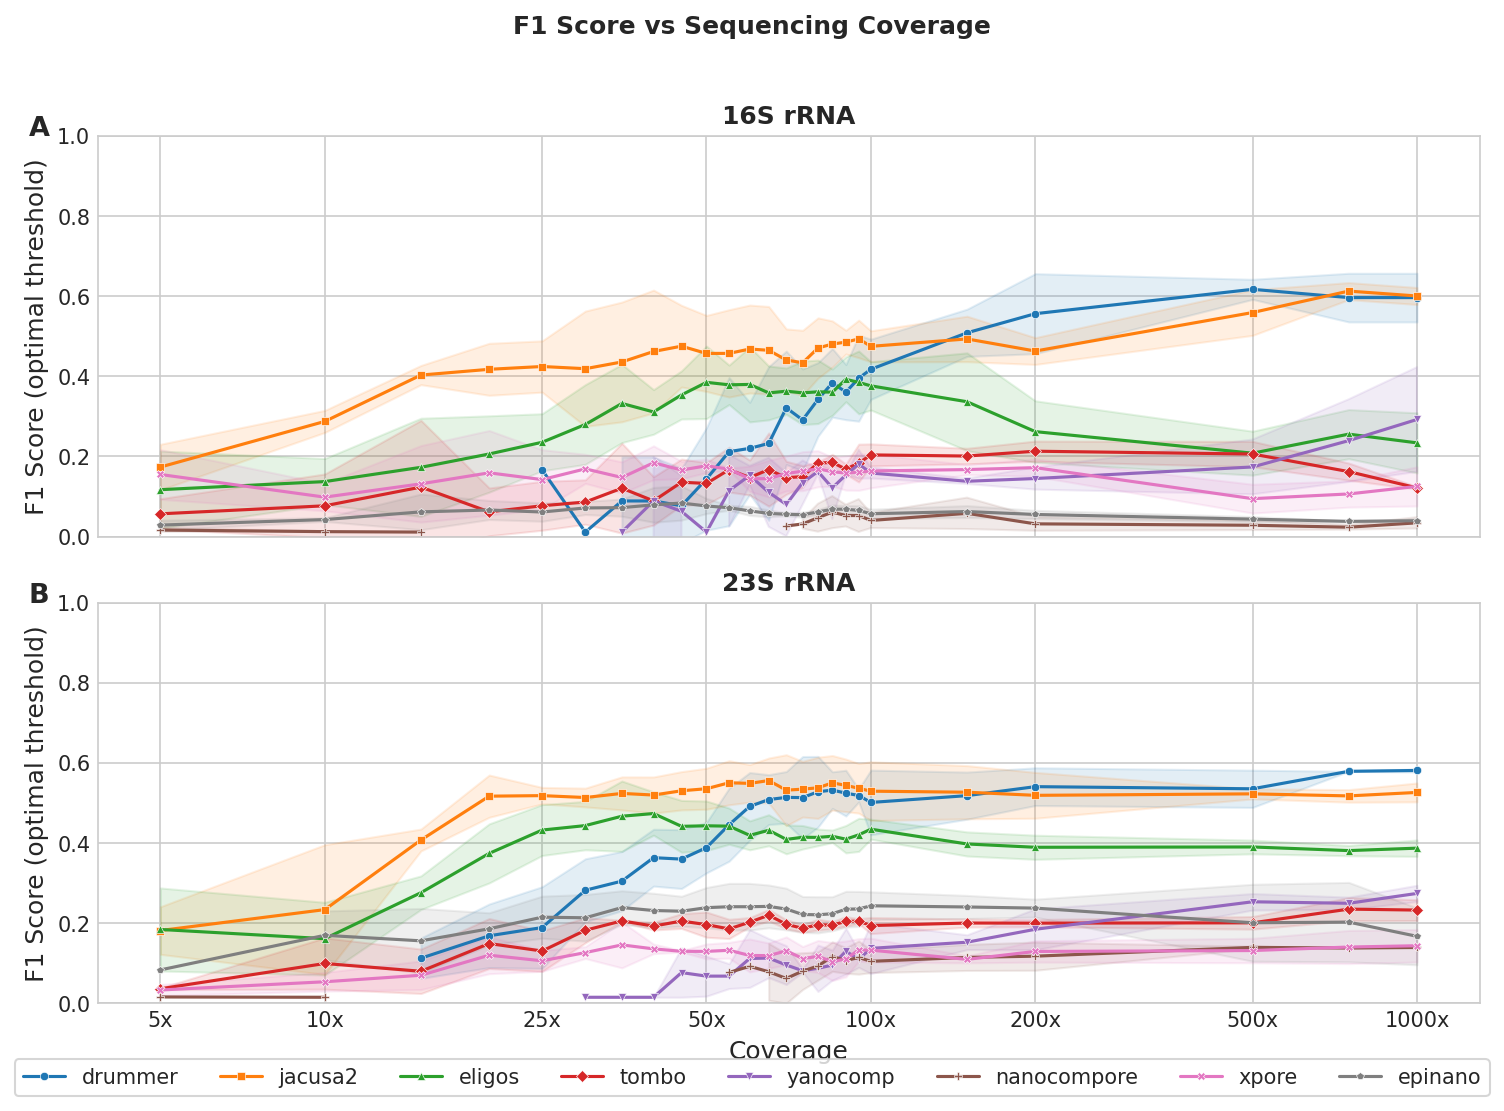

In [38]:
fig_f1 = plot_metric_vs_coverage(
    df_metrics,
    metric_mean='f1_optimal_mean', metric_std='f1_optimal_std',
    ylabel='F1 Score (optimal threshold)',
    title='F1 Score vs Sequencing Coverage',
    filename='f1_vs_coverage',
    ylim=(0.0, 1.0),
)

## Figure 4: AUROC Heatmap at Key Coverages

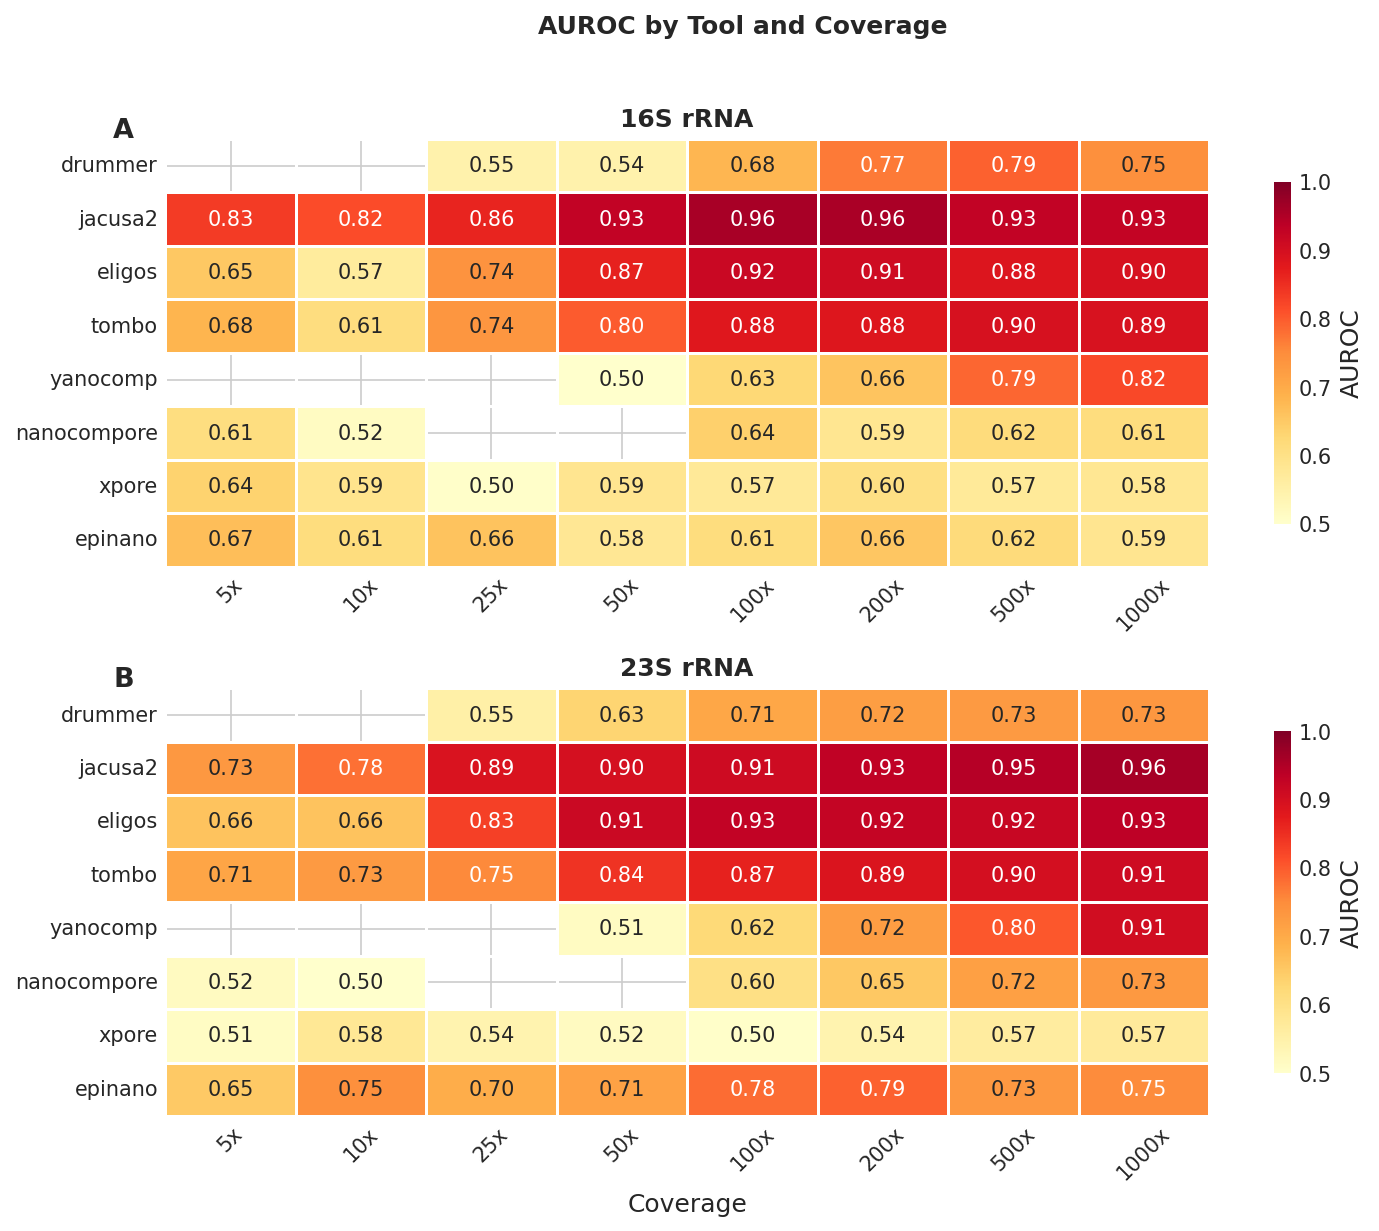

In [39]:
KEY_COVERAGES = [5, 10, 25, 50, 100, 200, 500, 1000]
refs = ['16s_88_rrsE', '23s_78_rrlB']

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

for ax, ref in zip(axes, refs):
    sub = df_metrics[(df_metrics['reference'] == ref) &
                     (df_metrics['coverage_num'].isin(KEY_COVERAGES))]
    pivot = sub.pivot_table(index='tool', columns='coverage_num',
                            values='auroc_mean', aggfunc='first')
    pivot = pivot.reindex(index=tools_with_metrics, columns=KEY_COVERAGES)

    sns.heatmap(pivot, ax=ax, annot=True, fmt='.2f', cmap='YlOrRd',
                vmin=0.5, vmax=1.0, linewidths=0.5, linecolor='white',
                cbar_kws={'label': 'AUROC', 'shrink': 0.8})
    ax.set_title(REF_LABELS[ref], fontweight='bold')
    ax.set_ylabel('')
    ax.set_xticklabels([f'{c}x' for c in KEY_COVERAGES], rotation=45)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

axes[0].set_xlabel('')
axes[1].set_xlabel('Coverage')

for i, label in enumerate(['A', 'B']):
    axes[i].text(-0.05, 1.05, label, transform=axes[i].transAxes,
                 fontsize=13, fontweight='bold', va='top')

fig.suptitle('AUROC by Tool and Coverage', fontsize=12, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / 'heatmap_auroc.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'heatmap_auroc.png', bbox_inches='tight')
plt.show()

## Figure 5: Tool Ranking Bar Plot at Selected Coverage

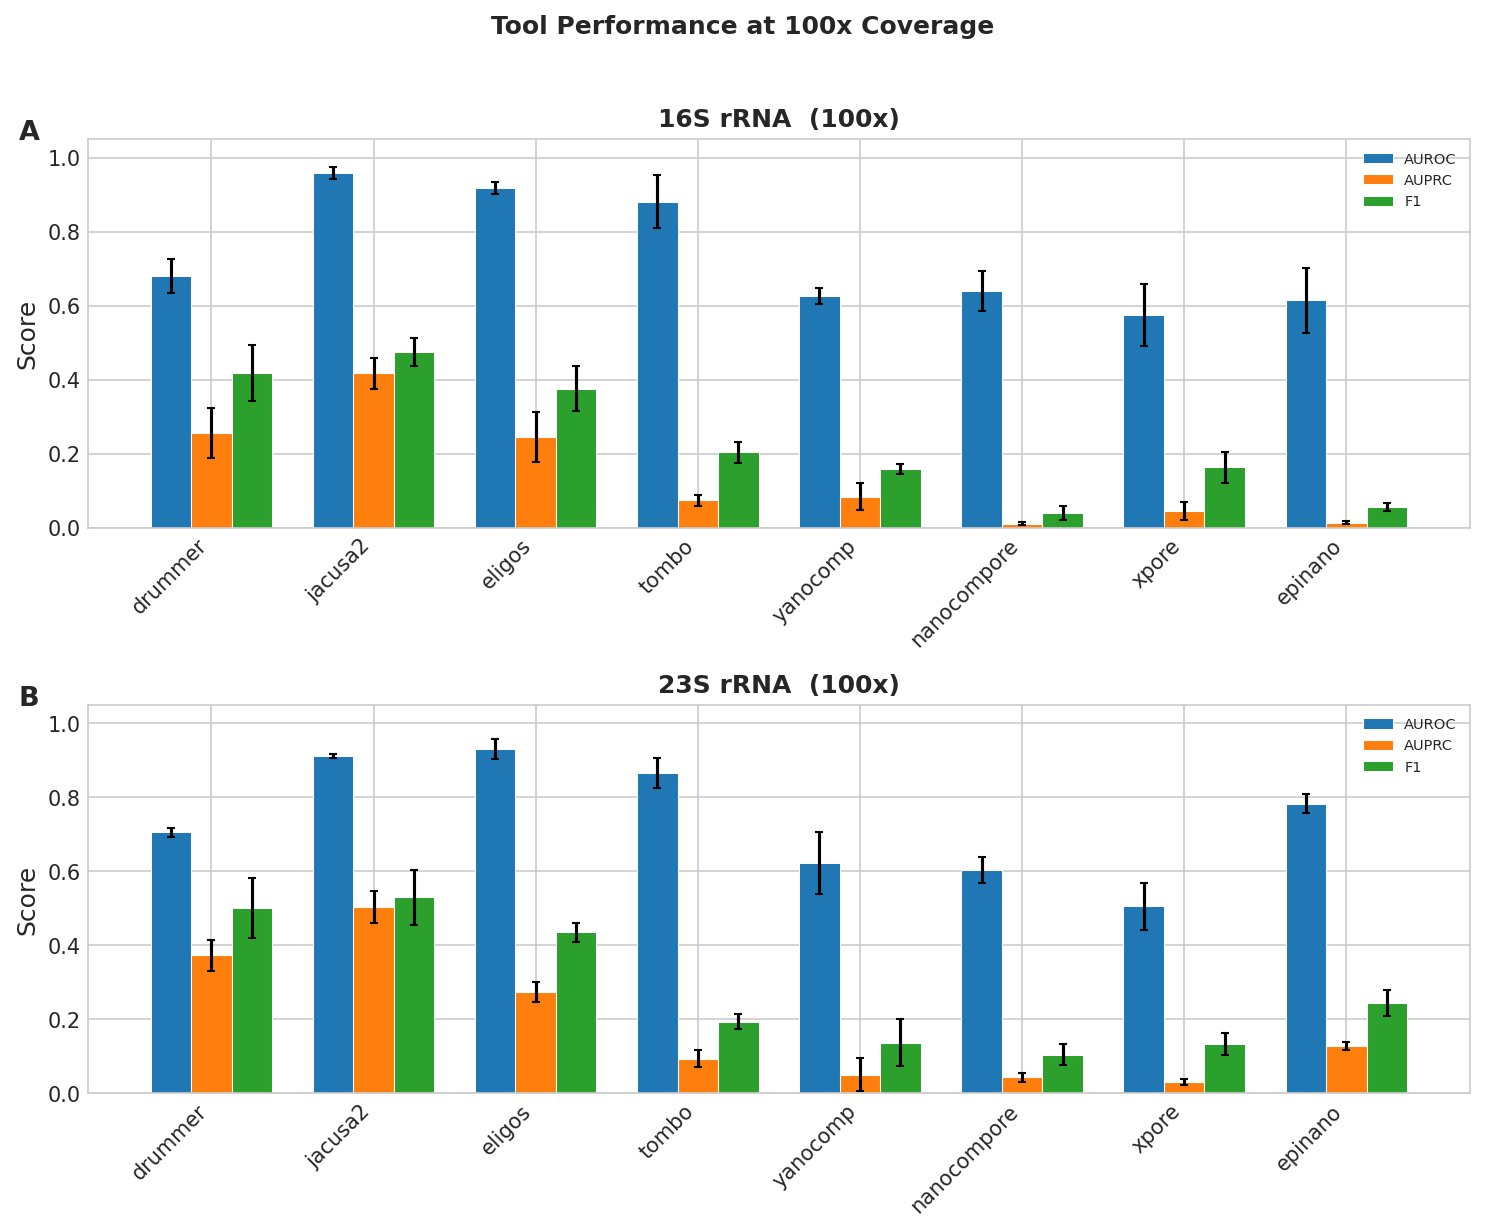

In [40]:
CHOSEN_COV = 100  # change to any coverage of interest

refs = ['16s_88_rrsE', '23s_78_rrlB']
metrics_to_plot = [
    ('auroc_mean', 'auroc_std', 'AUROC'),
    ('auprc_mean', 'auprc_std', 'AUPRC'),
    ('f1_optimal_mean', 'f1_optimal_std', 'F1'),
]

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharey=True)

for ax, ref in zip(axes, refs):
    sub = df_metrics[(df_metrics['reference'] == ref) &
                     (df_metrics['coverage_num'] == CHOSEN_COV)].copy()
    sub = sub.set_index('tool').reindex(tools_with_metrics)

    x = np.arange(len(tools_with_metrics))
    width = 0.25

    for i, (mean_col, std_col, label) in enumerate(metrics_to_plot):
        vals = sub[mean_col].values.astype(float)
        errs = sub[std_col].values.astype(float)
        errs = np.nan_to_num(errs)
        ax.bar(x + i * width, vals, width, yerr=errs,
               label=label, capsize=2, edgecolor='white', linewidth=0.5)

    ax.set_xticks(x + width)
    ax.set_xticklabels(tools_with_metrics, rotation=45, ha='right')
    ax.set_title(f"{REF_LABELS[ref]}  ({CHOSEN_COV}x)", fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Score')
    ax.legend(loc='upper right', fontsize=7)

for i, label in enumerate(['A', 'B']):
    axes[i].text(-0.05, 1.05, label, transform=axes[i].transAxes,
                 fontsize=13, fontweight='bold', va='top')

fig.suptitle(f'Tool Performance at {CHOSEN_COV}x Coverage', fontsize=12,
             fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / f'bar_tool_ranking_{CHOSEN_COV}x.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / f'bar_tool_ranking_{CHOSEN_COV}x.png', bbox_inches='tight')
plt.show()

## Figure 6: No-Call Rate & Ground Truth Recall vs Coverage

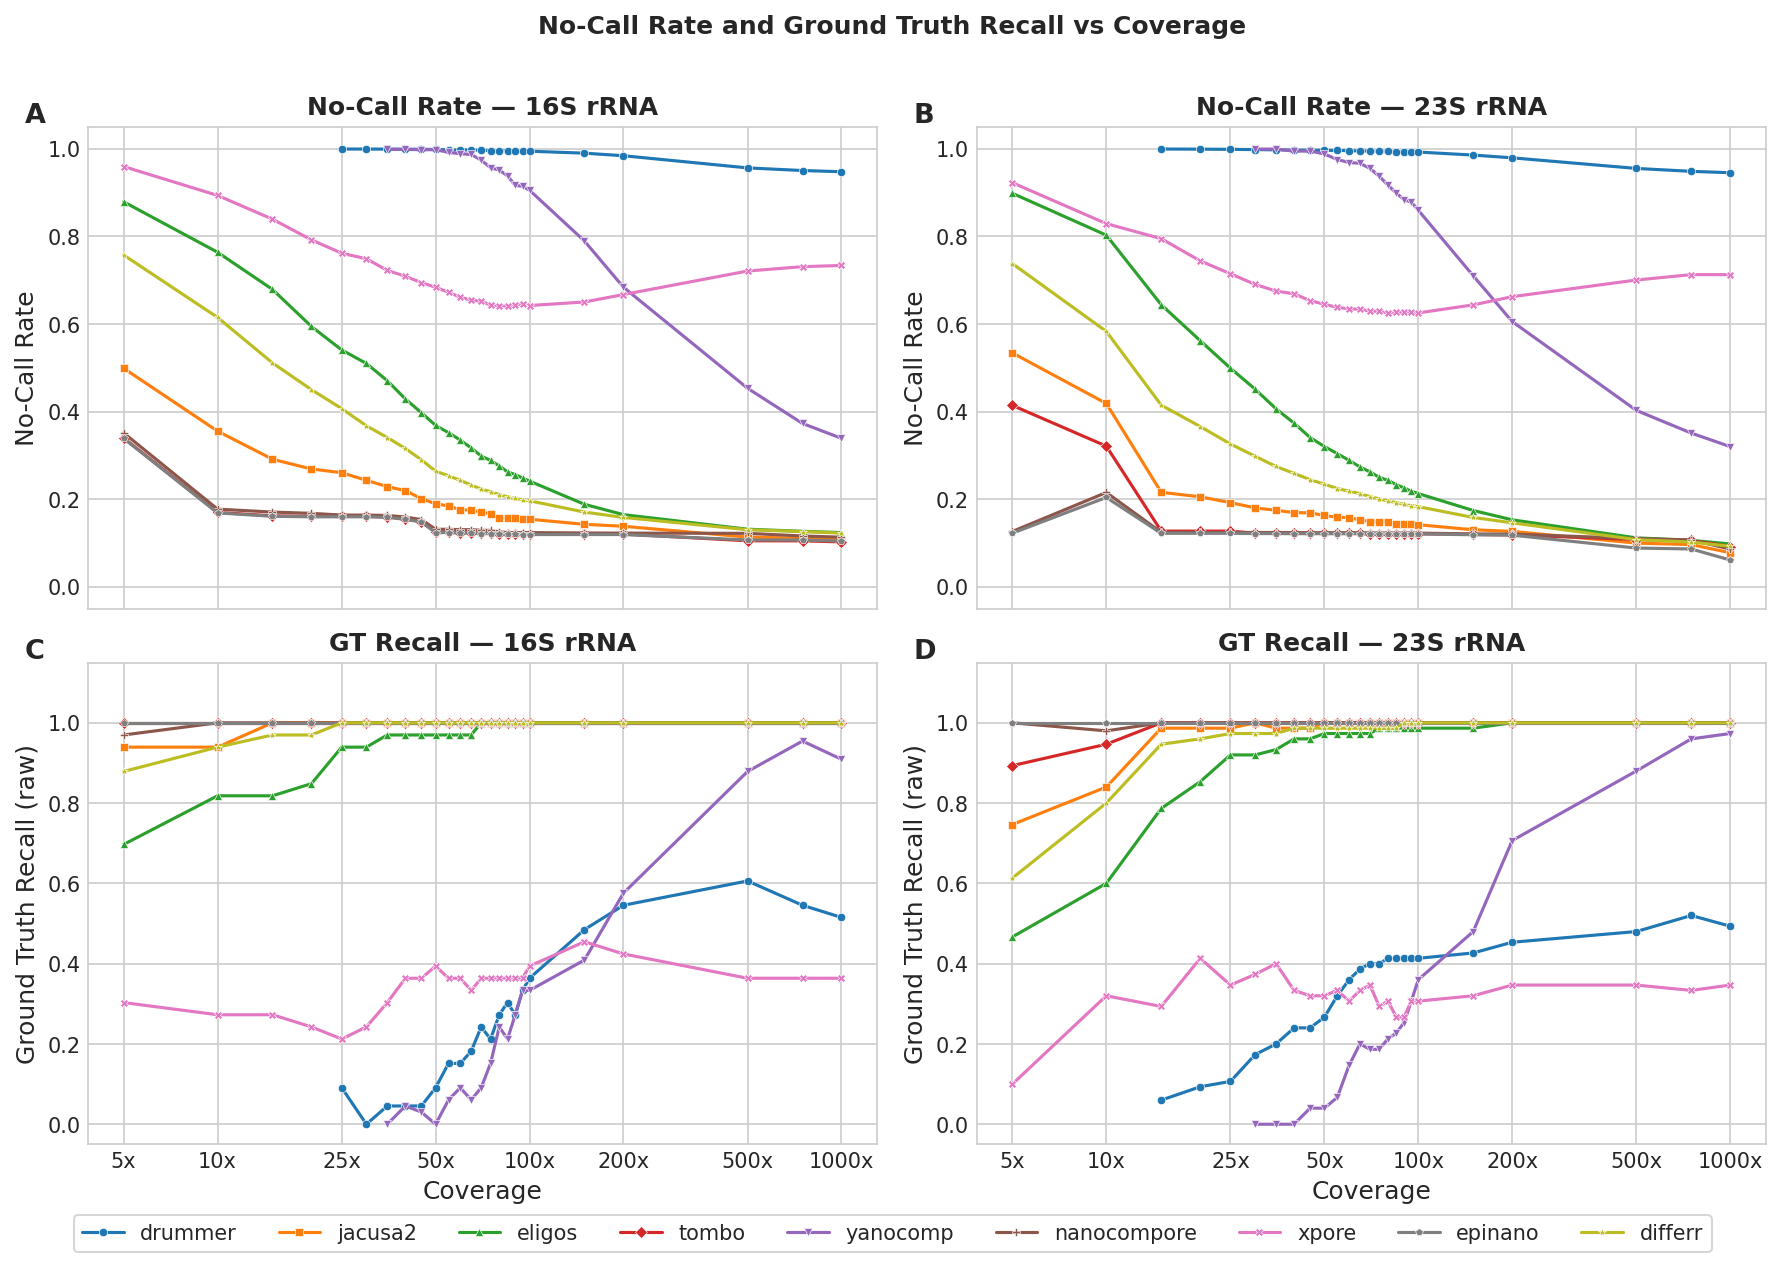

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

refs = ['16s_88_rrsE', '23s_78_rrlB']

for j, ref in enumerate(refs):
    sub = df[df['reference'] == ref]  # include differr here

    # No-call rate
    ax_nc = axes[0, j]
    for tool in TOOL_ORDER:
        t = sub[sub['tool'] == tool].sort_values('coverage_num')
        if t.empty:
            continue
        ax_nc.plot(t['coverage_num'], t['no_call_rate_mean'],
                   color=TOOL_COLORS[tool], marker=TOOL_MARKERS[tool],
                   label=tool, markeredgecolor='white', markeredgewidth=0.3)
    ax_nc.set_xscale('log')
    ax_nc.set_ylabel('No-Call Rate')
    ax_nc.set_title(f"No-Call Rate \u2014 {REF_LABELS[ref]}", fontweight='bold')
    ax_nc.set_ylim(-0.05, 1.05)
    ax_nc.xaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{int(v)}x'))
    ax_nc.set_xticks([5, 10, 25, 50, 100, 200, 500, 1000])

    # GT recall
    ax_gt = axes[1, j]
    for tool in TOOL_ORDER:
        t = sub[sub['tool'] == tool].sort_values('coverage_num')
        if t.empty:
            continue
        ax_gt.plot(t['coverage_num'], t['gt_recall_raw_mean'],
                   color=TOOL_COLORS[tool], marker=TOOL_MARKERS[tool],
                   label=tool, markeredgecolor='white', markeredgewidth=0.3)
    ax_gt.set_xscale('log')
    ax_gt.set_ylabel('Ground Truth Recall (raw)')
    ax_gt.set_xlabel('Coverage')
    ax_gt.set_title(f"GT Recall \u2014 {REF_LABELS[ref]}", fontweight='bold')
    ax_gt.set_ylim(-0.05, 1.15)
    ax_gt.xaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{int(v)}x'))
    ax_gt.set_xticks([5, 10, 25, 50, 100, 200, 500, 1000])

# Panel labels
panel_labels = [['A', 'B'], ['C', 'D']]
for i in range(2):
    for j in range(2):
        axes[i, j].text(-0.08, 1.05, panel_labels[i][j],
                        transform=axes[i, j].transAxes,
                        fontsize=13, fontweight='bold', va='top')

# Shared legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=min(len(TOOL_ORDER), 9),
           bbox_to_anchor=(0.5, -0.03), frameon=True)

fig.suptitle('No-Call Rate and Ground Truth Recall vs Coverage',
             fontsize=12, fontweight='bold', y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / 'nocall_gt_recall.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'nocall_gt_recall.png', bbox_inches='tight')
plt.show()

## Utility: Save Figure Helper

In [42]:
def save_fig(fig, name, formats=('pdf', 'png', 'svg')):
    """Save a figure in multiple formats to the figures directory."""
    for fmt in formats:
        path = FIG_DIR / f'{name}.{fmt}'
        fig.savefig(path, bbox_inches='tight', dpi=300 if fmt == 'png' else None)
        print(f'  Saved: {path}')

print(f'Figures saved to: {FIG_DIR.resolve()}')
print(f'Files:')
for f in sorted(FIG_DIR.glob('*')):
    print(f'  {f.name}')

Figures saved to: /absolute/path/to/user/tool_figures/figures
Files:
  auprc_ratio_vs_coverage.pdf
  auprc_ratio_vs_coverage.png
  auprc_vs_coverage.pdf
  auprc_vs_coverage.png
  auroc_vs_coverage.pdf
  auroc_vs_coverage.png
  bar_tool_ranking_100x.pdf
  bar_tool_ranking_100x.png
  f1_vs_coverage.pdf
  f1_vs_coverage.png
  heatmap_auroc.pdf
  heatmap_auroc.png
  nocall_gt_recall.pdf
  nocall_gt_recall.png
